# M2 — Is the frozen PFN surrogate trustworthy? (risk gate for §2.12)

Implements `docs/ROADMAP.md` §3 M2's exit criterion: standalone BO quality
with the frozen PFN as the surrogate (posterior mean/EI computed off its
predictive distribution), compared against a classical baseline on the
*same* tasks — a plain BoTorch GP + EI, per this project's own note
(the roadmap originally named PFNs4BO's HEBO+ model; a from-scratch
comparison against a code-identical-family GP+EI baseline is more useful
here and is what `models/baselines/gp_acquisition.py` already builds).

**Why this check exists (§2.12):** everything from M4 onward reads the PFN
as a stand-in for a real posterior. PFNs4BO's own strongest model is
trained on a *different* prior (HEBO+ GP) than this project's own
environment (the BNN prior, §1.6 — required, since only a callable
ground-truth environment supports the branch-and-replay data generation the
whole design depends on). So the prior that makes the best *environment*
might not make the best *surrogate* — this notebook is the check for
whether the BNN-prior-trained PFN is good enough to build a policy on top
of, or whether it's already a ceiling before any Q-head training starts.

**Checkpoint used:** `models/pfn_variable_xdim_smoke.pt`. Its experiment
config's own comment claims "Not a serious training run... 500 steps" —
**that comment is stale**: the checkpoint's own logged `history` (read
below) shows it actually trained for far longer. Trust the checkpoint's
logged history over the config comment when the two disagree.

**Method — a *shared task set*, per the exit criterion's wording:** each
policy (random, GP+EI, PFN-surrogate+EI) is rolled out against a
`BNNPrior` batch constructed with the *same seed*, so all three see
literally the same set of true functions (and the same initial `n_init`
context points) — differences in outcome are attributable to the policy,
not to which functions happened to be sampled. (Noise realizations along
each trajectory differ trivially anyway, since the policies query different
points — that's fine and unavoidable, unlike the function draws themselves.)

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import torch

from anytimeacquisition.metrics.inc_auc import log_incumbent_auc
from anytimeacquisition.metrics.rollout import random_policy, rollout_episode
from anytimeacquisition.models.baselines.gp_acquisition import gp_acquisition_policy
from anytimeacquisition.models.surrogates.pfn_surrogate import PFNSurrogate, pfn_surrogate_ei_policy
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

pfn, bar_dist, ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt")
surrogate = PFNSurrogate(pfn, bar_dist, use_bf16=False)  # bf16 autocast on CPU: correct but no speedup here
print(f"checkpoint config: {ckpt['config']}")
print(f"checkpoint actually trained for {max(ckpt['history']['step'])} steps "
      f"({len(ckpt['history']['step'])} logged points) -- ignore the experiment config's stale comment")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}
checkpoint actually trained for 29999 steps (301 logged points) -- ignore the experiment config's stale comment


## Run the shared-task comparison

In [2]:
BATCH_SIZE = 10  # 10 independent environments (BNN function draws) per x_dim, shared across all 3 policies
N_INIT, N_STEPS = 3, 12
POLICY_SEED = 1  # candidate-proposal randomness (GP restarts, PFN's Sobol pool) -- independent of the task seed

POLICIES = {
    "random": lambda: random_policy,
    "gp_ei": lambda: partial(gp_acquisition_policy, acquisition="EI", num_restarts=5, raw_samples=64),
    "pfn_surrogate_ei": lambda: partial(pfn_surrogate_ei_policy, surrogate=surrogate, n_candidates=256, seed=POLICY_SEED),
}


def run_shared_task_comparison(x_dim: int, task_seed: int = 0):
    rollouts = {}
    for name, make_policy in POLICIES.items():
        torch.manual_seed(task_seed)
        prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=x_dim, seed=task_seed)  # same seed -> same functions
        rollouts[name] = rollout_episode(prior, n_init=N_INIT, n_steps=N_STEPS, policy_fn=make_policy())
    return rollouts


results = {}
for x_dim in (1, 2):
    rollouts = run_shared_task_comparison(x_dim)
    aucs = {name: log_incumbent_auc(r["y_context"]) for name, r in rollouts.items()}
    results[x_dim] = {"rollouts": rollouts, "aucs": aucs}
    print(f"--- x_dim={x_dim} (lower log-incumbent AUC is better) ---")
    for name, auc in aucs.items():
        se = auc.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {auc.mean().item():8.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    gap = aucs["pfn_surrogate_ei"].mean().item() - aucs["gp_ei"].mean().item()
    print(f"  gap (pfn - gp, positive = GP still better): {gap:+.4f}")

--- x_dim=1 (lower log-incumbent AUC is better) ---
  random               mean -20.2902  +/- 6.8688 (se, n=10)
  gp_ei                mean -19.8996  +/- 6.8641 (se, n=10)
  pfn_surrogate_ei     mean -21.6950  +/- 7.8391 (se, n=10)
  gap (pfn - gp, positive = GP still better): -1.7954


--- x_dim=2 (lower log-incumbent AUC is better) ---
  random               mean -14.5803  +/- 2.1850 (se, n=10)
  gp_ei                mean -15.0559  +/- 2.5461 (se, n=10)
  pfn_surrogate_ei     mean -15.3454  +/- 2.4212 (se, n=10)
  gap (pfn - gp, positive = GP still better): -0.2895


## Incumbent trajectories — individual environments, not just the mean

Every one of the `BATCH_SIZE` (10) shared environments' own incumbent curve,
per policy (thin lines) plus the mean across them (bold) — a mean alone
hides whether a policy is consistently decent or a mix of great-and-terrible
runs averaging out to a plausible-looking number, which matters given how
large the standard errors on the summary AUC table above can be.

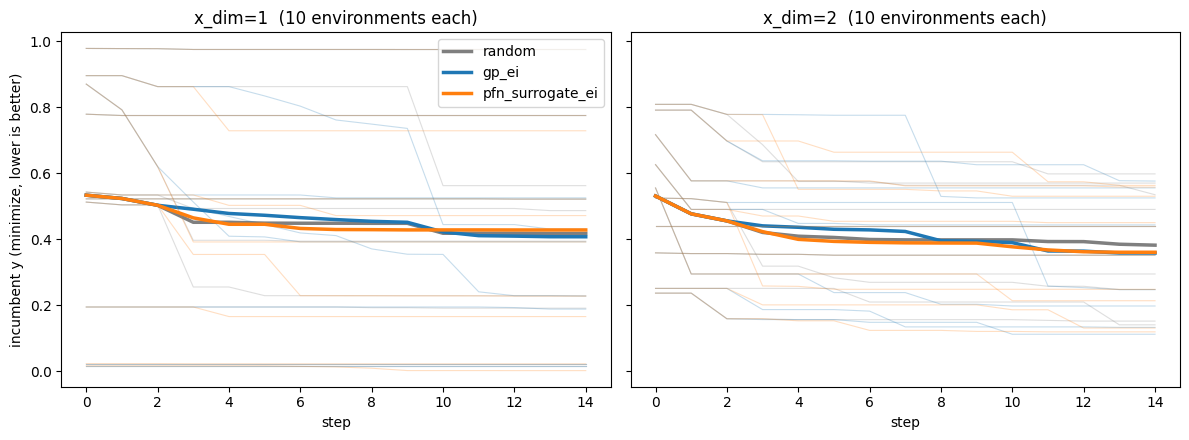

In [3]:
POLICY_COLORS = {"random": "tab:gray", "gp_ei": "tab:blue", "pfn_surrogate_ei": "tab:orange"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, x_dim in zip(axes, (1, 2)):
    for name, r in results[x_dim]["rollouts"].items():
        incumbent = torch.cummin(r["y_context"], dim=1).values  # minimize convention, [BATCH_SIZE, T]
        color = POLICY_COLORS[name]
        for row in incumbent:
            ax.plot(row, color=color, alpha=0.25, linewidth=0.8)
        ax.plot(incumbent.mean(dim=0), color=color, linewidth=2.5, label=name)
    ax.set_title(f"x_dim={x_dim}  ({BATCH_SIZE} environments each)")
    ax.set_xlabel("step")
axes[0].set_ylabel("incumbent y (minimize, lower is better)")
axes[0].legend()
plt.tight_layout()
plt.show()

## Cost curve: PFN forward time vs. context size `t` and candidate pool `C`

Second half of M2's exit criterion — confirms the `O(t(t+C))` attention
term and `O(C)` MLP term (§2.10), and gives a concrete number to pick `C`
from for later milestones' decision-time candidate pools.

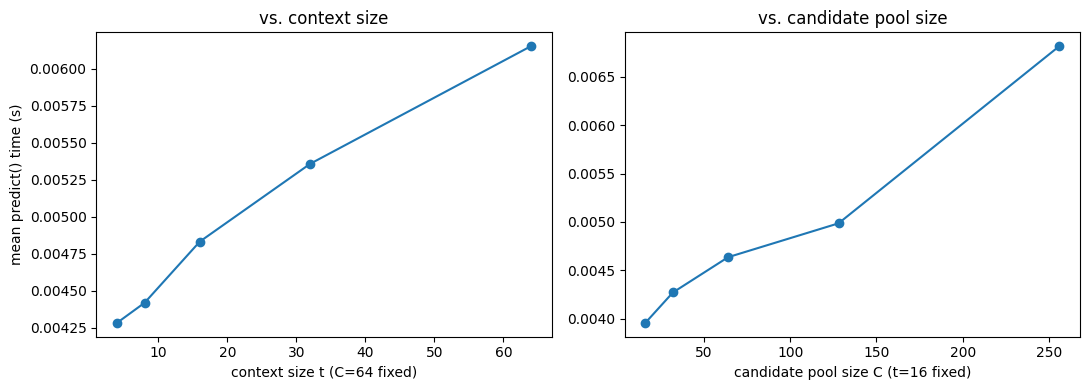

t=  4  C=64   predict() time: 4.28 ms
t=  8  C=64   predict() time: 4.42 ms
t= 16  C=64   predict() time: 4.83 ms
t= 32  C=64   predict() time: 5.36 ms
t= 64  C=64   predict() time: 6.15 ms
t=16  C=  16  predict() time: 3.96 ms
t=16  C=  32  predict() time: 4.27 ms
t=16  C=  64  predict() time: 4.64 ms
t=16  C= 128  predict() time: 4.99 ms
t=16  C= 256  predict() time: 6.82 ms


In [4]:
import time

def time_predict(t, C, n_repeats=5):
    prior = BNNPrior(batch_size=8, x_dim=2, seed=0)
    x_context, y_context, _, _ = prior.sample_episode(n_train=t, n_test=0)
    candidates = torch.rand(8, C, 2)
    surrogate.predict(x_context, y_context, candidates)  # warm-up (lazy imports, etc.)
    start = time.perf_counter()
    for _ in range(n_repeats):
        surrogate.predict(x_context, y_context, candidates)
    return (time.perf_counter() - start) / n_repeats


t_values = [4, 8, 16, 32, 64]
C_values = [16, 32, 64, 128, 256]

time_vs_t = [time_predict(t=t, C=64) for t in t_values]
time_vs_C = [time_predict(t=16, C=C) for C in C_values]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_values, time_vs_t, marker="o")
axes[0].set_xlabel("context size t (C=64 fixed)")
axes[0].set_ylabel("mean predict() time (s)")
axes[0].set_title("vs. context size")
axes[1].plot(C_values, time_vs_C, marker="o")
axes[1].set_xlabel("candidate pool size C (t=16 fixed)")
axes[1].set_title("vs. candidate pool size")
plt.tight_layout()
plt.show()

for t, dt in zip(t_values, time_vs_t):
    print(f"t={t:3d}  C=64   predict() time: {dt*1000:.2f} ms")
for C, dt in zip(C_values, time_vs_C):
    print(f"t=16  C={C:4d}  predict() time: {dt*1000:.2f} ms")

## Summary

Recorded in `docs/ROADMAP.md` §M2 — see the exit-criterion checklist there
for the actual numbers this run produced (they're printed above, not
hand-copied into this cell, so a rerun on a different/better-trained
checkpoint stays the source of truth).

**Reading the gap:** a positive `pfn - gp` gap means classical GP+EI still
beats the frozen PFN surrogate on this task set. Given the checkpoint
actually trained substantially longer than its stale config comment
claimed (see the "checkpoint actually trained for..." line above), these
numbers carry more weight than a smoke-scale reading would — still only
`BATCH_SIZE` (10) environments per dimension though, so treat this as an
informative first read, not the final word; widen `BATCH_SIZE` (and/or
average over several `task_seed`s) before leaning on it heavily.